# Inspect pretrained YOLO11-seg on blueprints

Zero-shot baseline using official COCO weights (`yolo11m-seg.pt`) with overlapping tiles so a 48x36" sheet is not letterboxed down to one 1280px image.

This model still looks for people, cars, chairs, and other COCO classes — not louvres, metal panels, or windows.

Point `INPUT` at a PDF, an image, or `pipeline/input` after dropping sheets there. Paths come from `infer.py` (`PROJECT_ROOT` / `DataCleaning` sibling). Restart the kernel after pipeline code changes.

In [1]:
from pathlib import Path
import importlib
import sys

PIPELINE_ROOT = Path("..").resolve()
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import infer
importlib.reload(infer)
from infer import DEFAULT_CONF, DEFAULT_IMGSZ, DEFAULT_MODEL, INPUT_DIR, OUTPUT_DIR, load_model

MODEL = DEFAULT_MODEL
model = load_model(MODEL)
print(f"Loaded {MODEL} with {len(model.names)} COCO classes")
print("run_inference args:", infer.run_inference.__code__.co_varnames)

Loaded /Users/junystephenli/Projects/TakeoffDetection/pipeline/weights/yolo11m-seg.pt with 80 COCO classes
run_inference args: ('pages', 'model', 'weights', 'imgsz', 'conf', 'tile_size', 'overlap', 'iou', 'results', 'page', 'n_tiles')


In [2]:
INPUT = INPUT_DIR / "UIH_ELEVATION.pdf"
OUTPUT = OUTPUT_DIR
IMGSZ = DEFAULT_IMGSZ
CONF = DEFAULT_CONF
DPI = 200
TILE_SIZE = 1280
OVERLAP = 0.2
IOU = 0.5

print(f"INPUT={INPUT}")
print(f"model={MODEL} imgsz={IMGSZ} conf={CONF} dpi={DPI}")
print(f"tile_size={TILE_SIZE} overlap={OVERLAP} iou={IOU}")

INPUT=/Users/junystephenli/Projects/TakeoffDetection/pipeline/input/UIH_ELEVATION.pdf
model=/Users/junystephenli/Projects/TakeoffDetection/pipeline/weights/yolo11m-seg.pt imgsz=1280 conf=0.25 dpi=200
tile_size=1280 overlap=0.2 iou=0.5


In [3]:
from infer import collect_pages

pages = collect_pages(INPUT, dpi=DPI)
for i, page in enumerate(pages):
    print(f"[{i}] {page['stem']}  {page['width']}x{page['height']}  {page['source']}")

[0] UIH_ELEVATION_p001  9600x7200  /Users/junystephenli/Projects/TakeoffDetection/pipeline/input/UIH_ELEVATION.pdf
[1] UIH_ELEVATION_p002  9600x7200  /Users/junystephenli/Projects/TakeoffDetection/pipeline/input/UIH_ELEVATION.pdf
[2] UIH_ELEVATION_p003  9600x7200  /Users/junystephenli/Projects/TakeoffDetection/pipeline/input/UIH_ELEVATION.pdf
[3] UIH_ELEVATION_p004  9600x7200  /Users/junystephenli/Projects/TakeoffDetection/pipeline/input/UIH_ELEVATION.pdf


In [4]:
import importlib
import infer
importlib.reload(infer)
from infer import run_inference

inferences = run_inference(
    pages,
    model=model,
    imgsz=IMGSZ,
    conf=CONF,
    tile_size=TILE_SIZE,
    overlap=OVERLAP,
    iou=IOU,
)
for item in inferences:
    print(f"{item.stem}: {len(item.detections)} detection(s)")

UIH_ELEVATION_p001: 70 tiles (9600x7200)
UIH_ELEVATION_p002: 70 tiles (9600x7200)
UIH_ELEVATION_p003: 70 tiles (9600x7200)
UIH_ELEVATION_p004: 70 tiles (9600x7200)
UIH_ELEVATION_p001: 2 detection(s)
UIH_ELEVATION_p002: 3 detection(s)
UIH_ELEVATION_p003: 1 detection(s)
UIH_ELEVATION_p004: 4 detection(s)


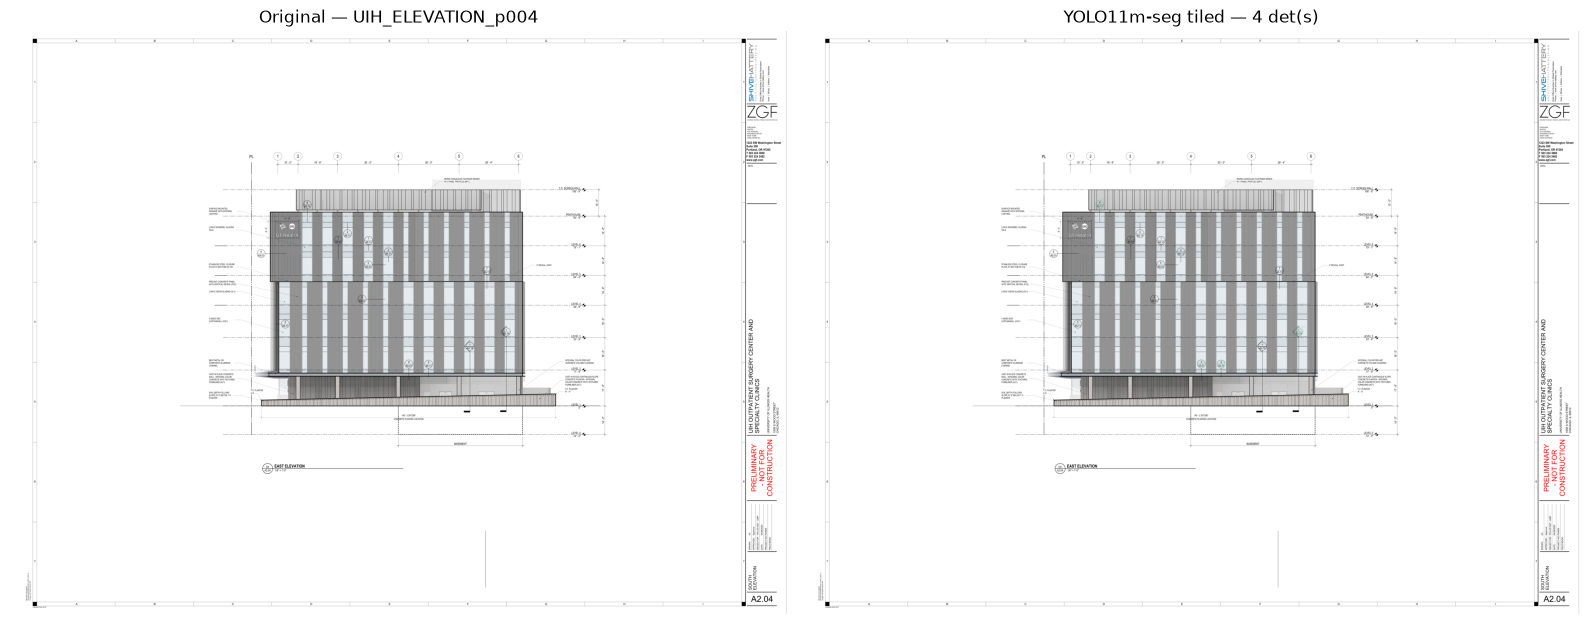

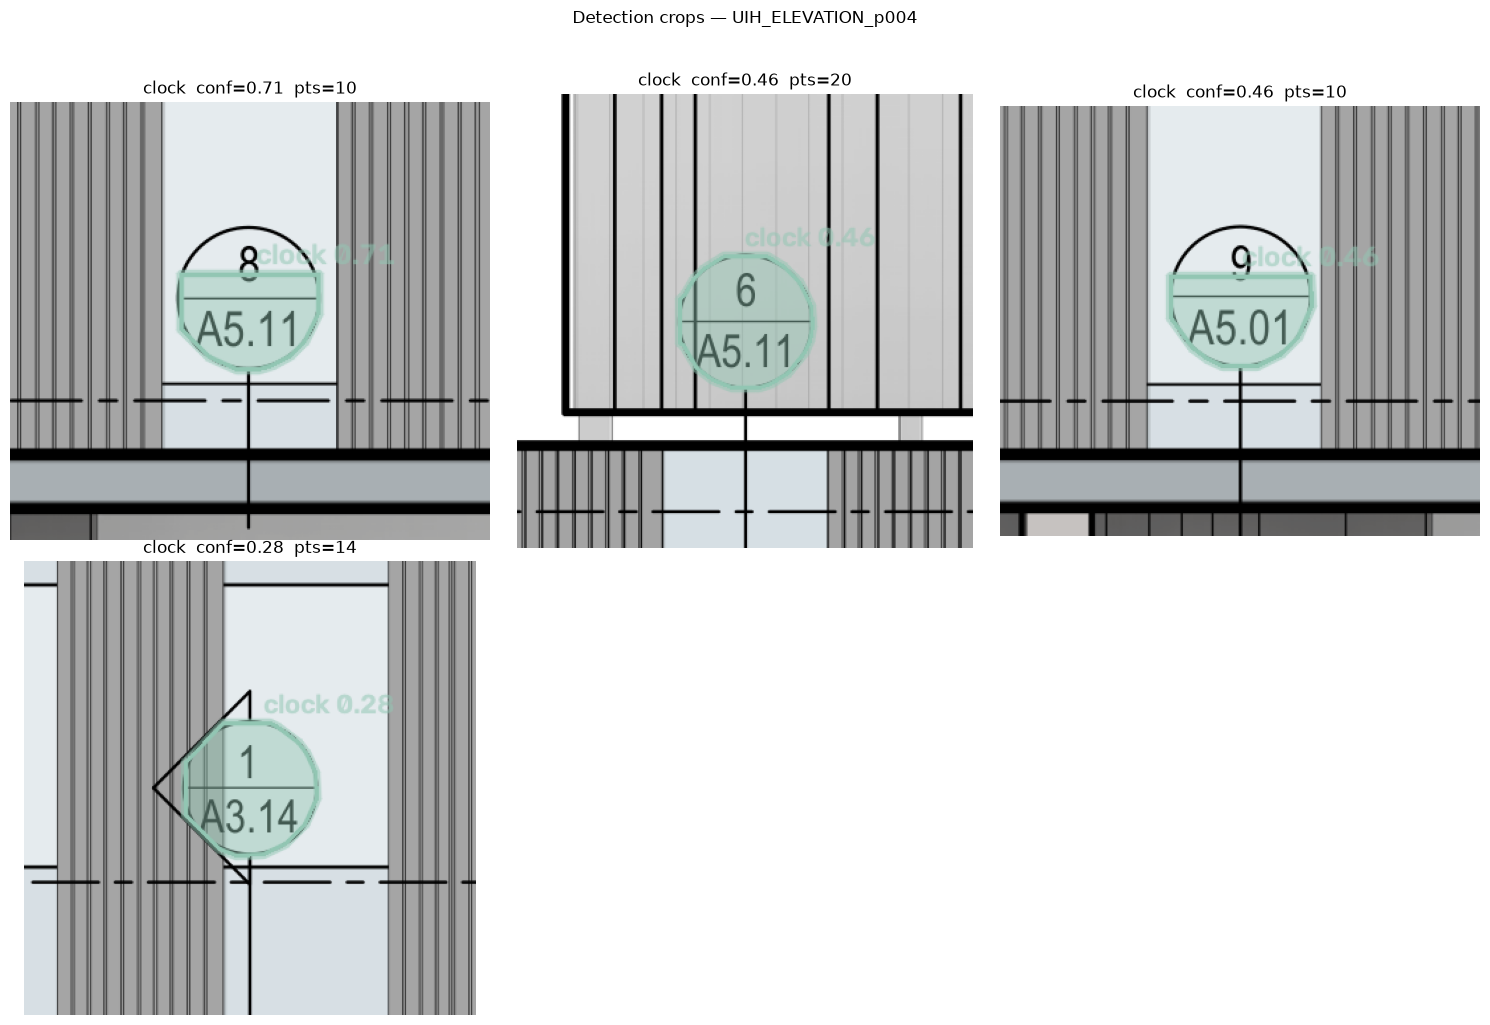

Page 4 of 4  |  change PAGE_INDEX and re-run


,class_name,class_id,confidence,bbox_xyxy,mask_points
0,clock,74,0.7094,"[5120.0, 4096.12, 5220.53, 4166.08]",10
1,clock,74,0.4611,"[3618.47, 2092.48, 3721.26, 2194.98]",20
2,clock,74,0.4610,"[4872.69, 4096.14, 4976.03, 4164.01]",10
3,clock,74,0.2755,"[6077.13, 3665.89, 6179.33, 3768.02]",14


In [5]:
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from infer import draw_detection_detail, draw_overlay

PAGE_INDEX = 3
CROP_PAD = 120

item = inferences[PAGE_INDEX]
rows = [
    {
        "class_name": det.class_name,
        "class_id": det.class_id,
        "confidence": det.confidence,
        "bbox_xyxy": det.bbox_xyxy,
        "mask_points": len(det.mask_polygon),
    }
    for det in item.detections
]
table = pd.DataFrame(rows)

# Full-page view with center markers on tiny detections (re-draw if kernel was not restarted).
full_overlay = draw_overlay(item.image_rgb, item.detections, show_center_markers=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(item.image_rgb)
axes[0].set_title(f"Original — {item.stem}")
axes[0].axis("off")
axes[1].imshow(full_overlay[:, :, ::-1])
axes[1].set_title(f"YOLO11m-seg tiled — {len(item.detections)} det(s)")
axes[1].axis("off")
fig.tight_layout()
plt.show()

if item.detections:
    n = len(item.detections)
    cols = min(3, n)
    rows_n = ceil(n / cols)
    fig, axes = plt.subplots(rows_n, cols, figsize=(5 * cols, 5 * rows_n))
    axes = np.atleast_1d(axes).ravel()

    for ax, det in zip(axes, item.detections):
        detail = draw_detection_detail(item.image_rgb, det, pad=CROP_PAD)
        ax.imshow(detail[:, :, ::-1])
        ax.set_title(f"{det.class_name}  conf={det.confidence:.2f}  pts={len(det.mask_polygon)}")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(f"Detection crops — {item.stem}", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("No detections on this page.")

print(f"Page {PAGE_INDEX + 1} of {len(inferences)}  |  change PAGE_INDEX and re-run")
table

In [6]:
from infer import save_results

json_path = save_results(inferences, OUTPUT)
print(f"Saved {len(inferences)} page(s) to {OUTPUT}")
print(json_path)

Saved 4 page(s) to /Users/junystephenli/Projects/TakeoffDetection/pipeline/output
/Users/junystephenli/Projects/TakeoffDetection/pipeline/output/detections.json
